# Humpback Whale Identification — Classification Baseline

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe

## Overview

This notebook implements an improved image classification baseline for humpback whale
identification from fluke photographs. The task is extremely challenging:
- ~4000+ whale identities, most with only 1–5 training images
- A large "new_whale" class representing unidentified individuals
- Fine-grained visual differences (trailing-edge notches, pigmentation patterns)

We systematically address the overfitting problem observed in naive approaches through:
1. **Appropriate augmentation** (conservative, preserving identity cues)
2. **Better backbone** (EfficientNet-B5 at 456px for fine-grained detail)
3. **Freeze/unfreeze training** (preserve pretrained features, then fine-tune)
4. **Focal Loss** (handles extreme class imbalance better than cross-entropy)
5. **Separate evaluation** of known-whale accuracy vs. new-whale detection

All hyperparameters are controlled via a single configuration object, experiments
are indexed and checkpointed automatically, and training can resume from any point.


## 1. Setup & Imports

In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure our project modules are importable
# (adjust this path if you've placed the files elsewhere)
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import prepare_data, build_dataloaders
from models import WhaleClassifier, print_model_summary
from losses import build_loss
from training import train, set_seed
from evaluation import evaluate
from visualization import plot_training_history, compare_experiments, list_experiments

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected. Training will be very slow.")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


GPU: NVIDIA GeForce RTX 3070
VRAM: 8.6 GB
PyTorch: 2.5.1+cu121
Device: cuda


## 2. Experiment Configuration

All hyperparameters live in a single `ExperimentConfig` dataclass.  
To run a new experiment, create a new config — previous results are preserved automatically.

### Key design decisions:
- **EfficientNet-B5 at 456×456**: native resolution for this model, captures fine fluke details
- **Batch size 8 × 4 accumulation = 32 effective**: fits in 8GB VRAM with AMP
- **Frozen BN**: pretrained batch norm statistics are more reliable than those from micro-batches
- **Focal Loss (γ=2.0)**: down-weights easy examples, focuses on hard/rare classes
- **3 epochs frozen backbone**: lets the new head learn sensible weights before fine-tuning begins


In [2]:
config = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="baseline_effnetb5_focal",
    description="EfficientNet-B5 with Focal Loss, freeze 3 epochs, 456px",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",               # Contains train.csv and train/ folder
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,

    # ── Freeze strategy ──────────────────────────────────────────
    freeze_backbone_epochs=3,
    freeze_bn=True,

    # ── Training ─────────────────────────────────────────────────
    epochs=30,
    batch_size=12,
    accumulation_steps=2,
    use_amp=True,

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=1e-3,
    lr_backbone=1e-4,
    weight_decay=1e-4,

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="focal",
    focal_gamma=2.0,
    label_smoothing=0.1,
    use_class_weights=True,

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=1,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=8,
    early_stopping_metric="val_known_acc",

    seed=42,
)

print("Experiment config:")
print(config.summary())


Experiment config:
efficientnet_b5 | 456px | focal(γ=2.0) | lr=0.0001/0.001 | freeze=3ep | bs=12×2


## 3. Data Preparation

The data pipeline:
1. Loads `train.csv` with (Image, Id) pairs
2. Uses a hybrid split: stratifies classes with enough samples and keeps ultra-rare classes in training
3. Excludes `new_whale` from training (it's not a class — it's the *absence* of a known class)
4. Keeps `new_whale` in validation to track open-set detection performance
5. Builds contiguous class indices for the known whale identities


In [3]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")


[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class

Class mapping: 4247 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


### 3.1 Exploratory Data Analysis

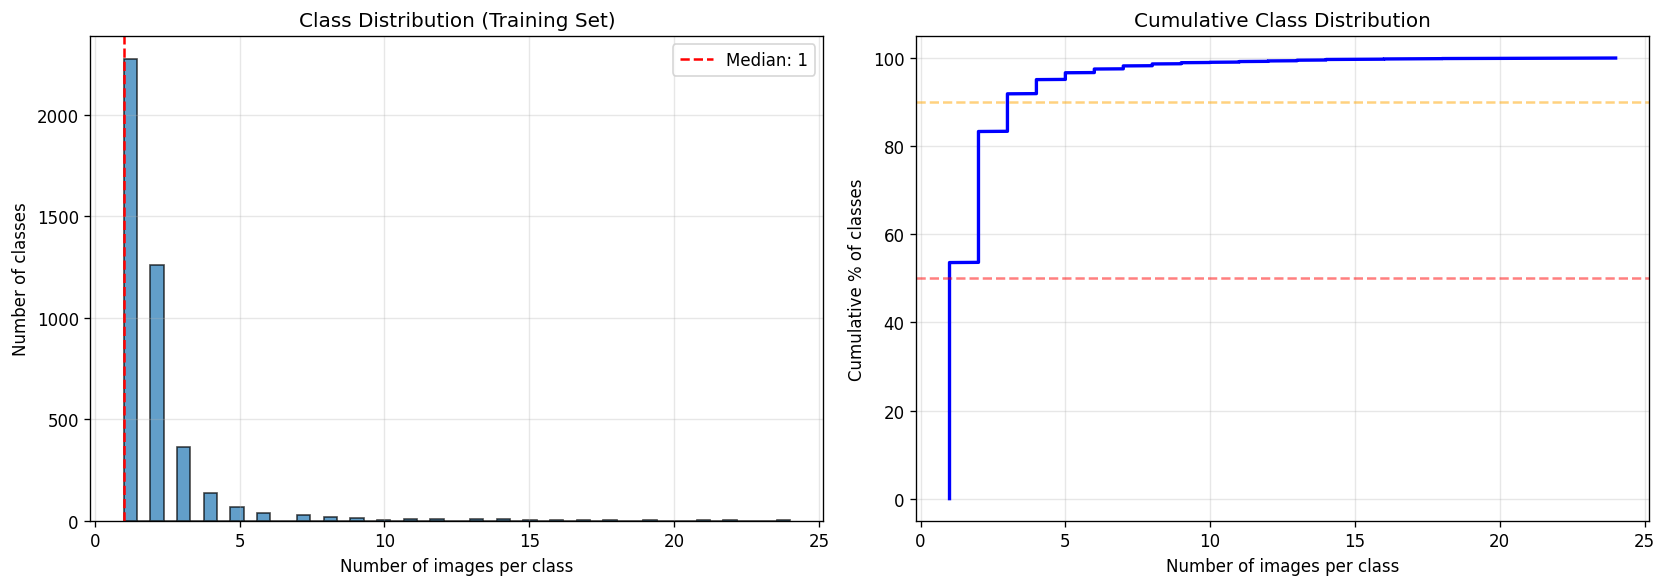

Classes with 1 image:   2276 (53.6%)
Classes with ≤ 2 images: 3539 (83.3%)
Classes with ≤ 5 images: 4105 (96.7%)


In [4]:
# Class distribution analysis
class_counts = data["class_counts"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of samples per class
ax = axes[0]
ax.hist(class_counts, bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Number of images per class")
ax.set_ylabel("Number of classes")
ax.set_title("Class Distribution (Training Set)")
ax.axvline(x=np.median(class_counts), color="red", linestyle="--",
           label=f"Median: {np.median(class_counts):.0f}")
ax.legend()
ax.grid(True, alpha=0.3)

# Cumulative: what fraction of classes have ≤ N images?
ax = axes[1]
sorted_counts = np.sort(class_counts)
cumulative = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100
ax.plot(sorted_counts, cumulative, "b-", linewidth=2)
ax.set_xlabel("Number of images per class")
ax.set_ylabel("Cumulative % of classes")
ax.set_title("Cumulative Class Distribution")
ax.axhline(y=50, color="red", linestyle="--", alpha=0.5)
ax.axhline(y=90, color="orange", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/class_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

# Key statistics
print(f"Classes with 1 image:   {(class_counts == 1).sum()} ({(class_counts == 1).sum() / len(class_counts) * 100:.1f}%)")
print(f"Classes with ≤ 2 images: {(class_counts <= 2).sum()} ({(class_counts <= 2).sum() / len(class_counts) * 100:.1f}%)")
print(f"Classes with ≤ 5 images: {(class_counts <= 5).sum()} ({(class_counts <= 5).sum() / len(class_counts) * 100:.1f}%)")


### 3.2 Sample Images

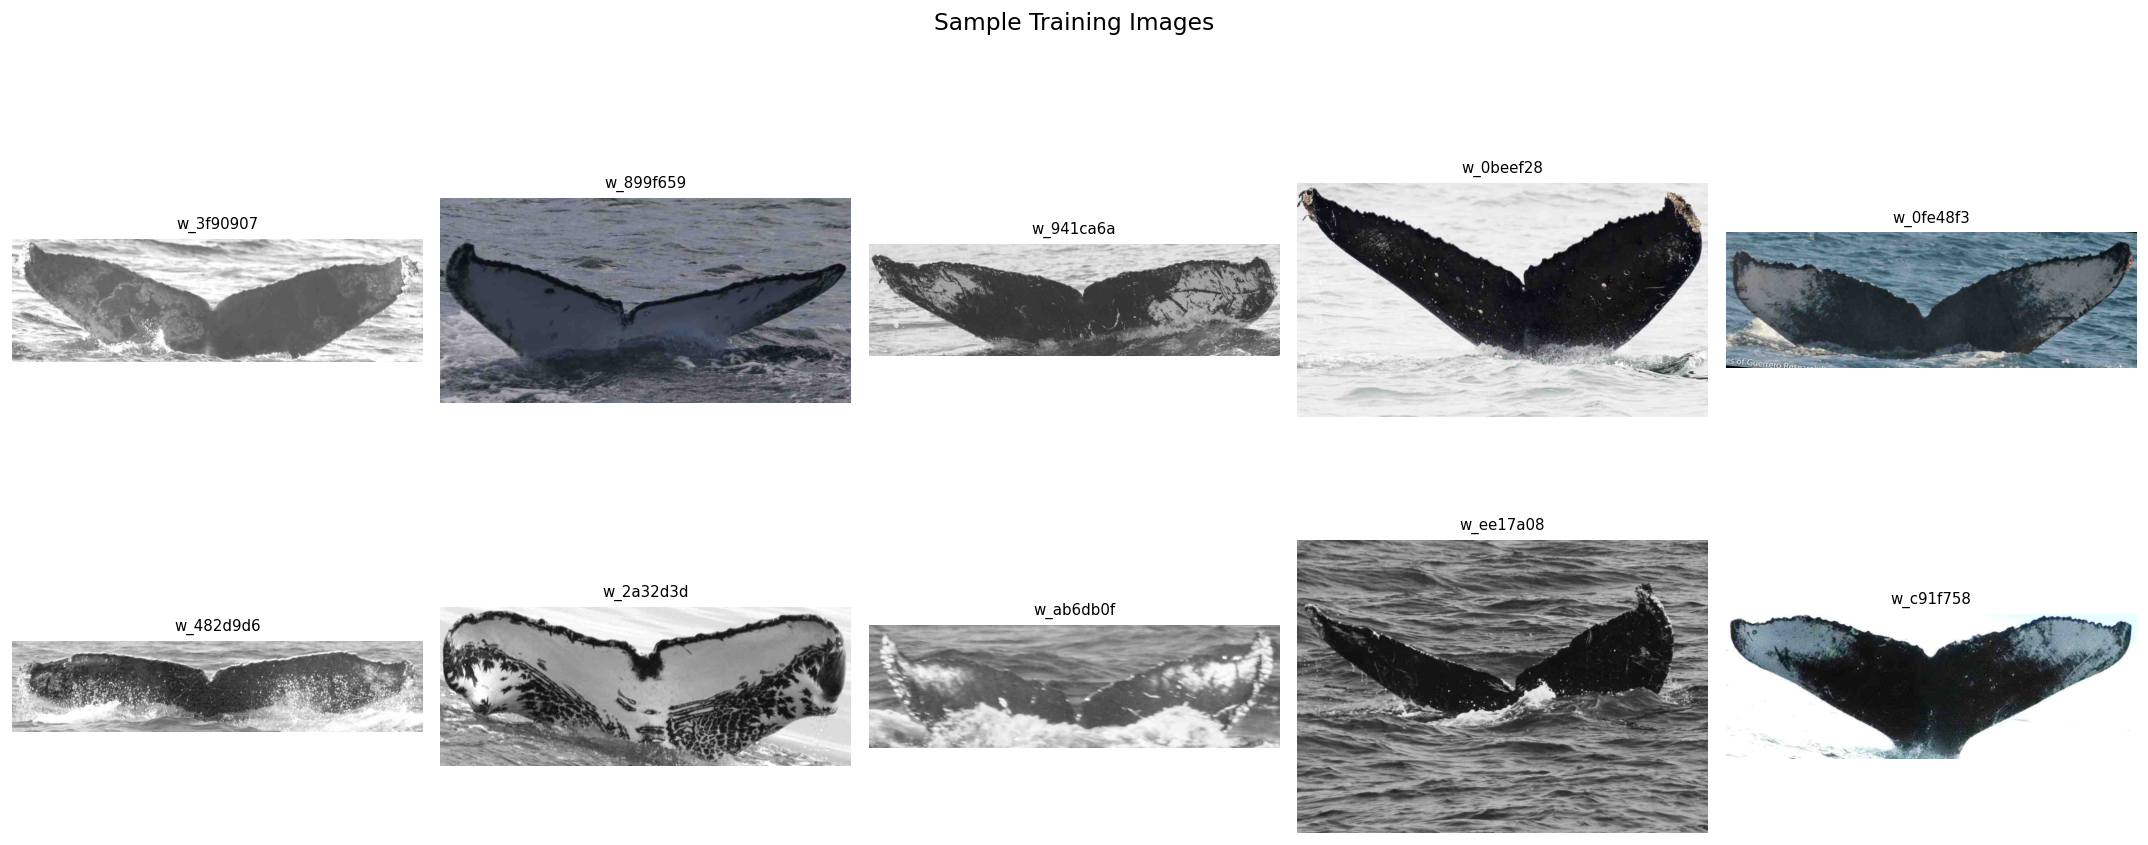

In [5]:
from dataset import build_val_transform
from PIL import Image as PILImage

# Show a few training images with their labels
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
sample_df = data["train_df"].sample(10, random_state=42)
transform = build_val_transform(config)

for i, (_, row) in enumerate(sample_df.iterrows()):
    ax = axes[i // 5, i % 5]
    img_path = os.path.join(config.data_dir, "train", row["Image"])
    try:
        img = PILImage.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(row["Id"][:15], fontsize=9)
    except:
        ax.text(0.5, 0.5, "Load error", ha="center")
    ax.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


## 4. Build DataLoaders

Augmentation philosophy for whale flukes:
- **YES**: Mild rotation, brightness/contrast jitter, slight crop variation, gentle blur
- **NO**: Horizontal flip (left/right notch patterns are identity-specific),
  random erasing (could delete the exact notch that identifies the whale),
  heavy geometric distortion (changes trailing-edge shape)


Train batches: 674 (micro-batch=12, effective=24)
Val batches:   24


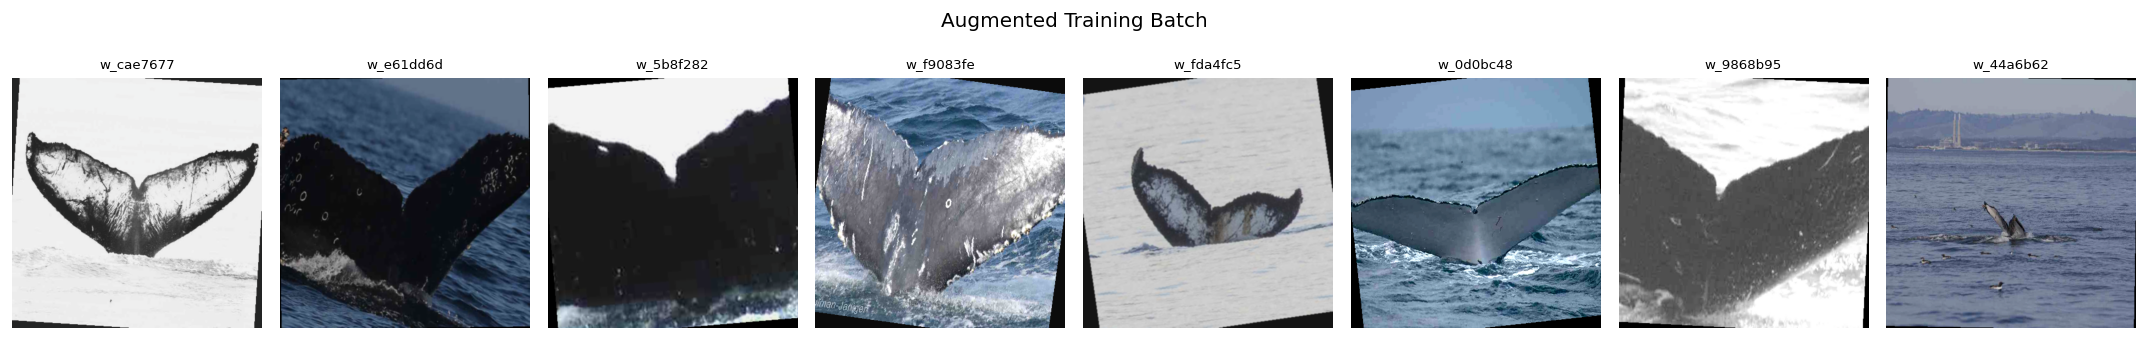

In [6]:
train_loader, val_loader = build_dataloaders(config, data)

print(f"Train batches: {len(train_loader)} (micro-batch={config.batch_size}, "
      f"effective={config.batch_size * config.accumulation_steps})")
print(f"Val batches:   {len(val_loader)}")

# Show a batch with augmentation applied
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, min(8, len(images)), figsize=(18, 3))

# Denormalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i, ax in enumerate(axes):
    img = images[i].cpu() * std + mean
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    label = labels[i].item()
    id_str = data["idx_to_id"].get(label, "new_whale") if label >= 0 else "new_whale"
    ax.set_title(f"{id_str[:12]}", fontsize=8)
    ax.axis("off")

plt.suptitle("Augmented Training Batch", fontsize=12)
plt.tight_layout()
plt.show()


## 5. Train

The training procedure has two phases:

**Phase 1 — Frozen backbone** (epochs 0–2):
Only the embedding layer and classifier head are trained. This lets the new
head learn sensible weights using stable pretrained features, preventing the
backbone from being corrupted by random gradients from the untrained head.

**Phase 2 — Full fine-tuning** (epochs 3+):
The backbone is unfrozen with a 10× lower learning rate than the head.
BatchNorm layers remain in eval mode throughout (their ImageNet statistics
are more reliable than statistics from our micro-batches).

Training uses:
- **AMP** (Automatic Mixed Precision) for ~50% memory reduction
- **Gradient accumulation** (4 steps) for effective batch size of 32
- **Cosine annealing** with linear warmup
- **Gradient clipping** at norm 1.0


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TRAIN
# ═══════════════════════════════════════════════════════════════════
# To resume a previous run, set resume_from to its experiment ID:
#   manager = train(config, data, device, resume_from="20260402_123456_baseline_abc12345")
# To start fresh:
manager = train(config, data, device)


[22:01:38] New experiment: 20260405_220138_baseline_effnetb5_focal_571ff8b8
[22:01:38] Config: efficientnet_b5 | 456px | focal(γ=2.0) | lr=0.0001/0.001 | freeze=3ep | bs=12×2
[22:01:38] No matching resume target found. Starting new experiment.
[22:01:39] Backbone FROZEN for first 3 epochs

Model: efficientnet_b5 (head=linear)
  Input size:     (456, 456)
  Embedding dim:  512
  Total params:     31,569,607
  Backbone:         28,340,784
  Head:              3,228,823
  Trainable:         3,228,823 (10.2%)
  Frozen:           28,340,784 (89.8%)

[22:01:39] Loss: focal | Head: linear
[22:01:39] 
Starting training: 30 epochs, effective batch size = 24


  Train Ep 0:   0%|          | 0/674 [00:06<?, ?it/s]

c:\Users\krios\Downloads\ML4CV\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  Val   Ep 0:   0%|          | 0/24 [00:07<?, ?it/s]

[22:03:25] Epoch   0/30 [FROZEN] | Train Loss: 6.4938  Acc: 1.3% | Val val_known_acc: 3.9%  NewWhale Det: 100.0% | LR: 1.00e-03 | Time: 1.8m
[22:03:46]   ✓ New best model saved (epoch 0, val_known_acc=0.0385)


...

[22:05:27] Epoch   1/30 [FROZEN] | Train Loss: 3.6501  Acc: 30.9% | Val val_known_acc: 7.5%  NewWhale Det: 96.7% | LR: 9.97e-04 | Time: 1.7m
[22:05:27]   ✓ New best model saved (epoch 1, val_known_acc=0.0749)


  Train Ep 2:   0%|          | 0/674 [00:06<?, ?it/s]

  Val   Ep 2:   0%|          | 0/24 [00:07<?, ?it/s]

[22:07:10] Epoch   2/30 [FROZEN] | Train Loss: 2.1802  Acc: 58.1% | Val val_known_acc: 10.5%  NewWhale Det: 95.6% | LR: 9.88e-04 | Time: 1.7m
[22:07:50]   ✓ New best model saved (epoch 2, val_known_acc=0.1049)
[22:07:50] 
[22:07:50] BACKBONE UNFROZEN at epoch 3
[22:07:50] ============================================================


Model: efficientnet_b5 (head=linear)
  Input size:     (456, 456)
  Embedding dim:  512
  Total params:     31,569,607
  Backbone:         28,340,784
  Head:              3,228,823
  Trainable:        31,569,607 (100.0%)
  Frozen:                    0 (0.0%)



  Train Ep 3:   0%|          | 0/674 [00:06<?, ?it/s]

## 6. Training Analysis

In [ ]:
# Load metrics from the completed experiment
import json

metrics_path = manager.root / "metrics.json"
with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)


In [ ]:
# Print final summary
print(f"Best epoch: {manager.best_epoch}")
print(f"Best {config.early_stopping_metric}: {manager.best_metric_value:.4f}")

print(f"\nFinal metrics (last epoch):")
for key in ["train_loss", "train_acc", "val_loss", "val_known_acc",
            "val_new_whale_detection", "val_overall_acc", "val_mean_confidence"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")


## 7. Evaluate Best Model

Load the best checkpoint and run detailed evaluation.


In [ ]:
# Load best model
from models import WhaleClassifier

best_model = WhaleClassifier(
    backbone_name=config.backbone,
    num_classes=data["num_classes"],
    embedding_dim=config.embedding_dim,
    pretrained=False,  # We'll load our trained weights
).to(device)

manager.load_checkpoint(best_model, checkpoint="best")

# Run evaluation
criterion = build_loss(config, data["class_counts"], device)
val_metrics = evaluate(best_model, val_loader, criterion, config, device, epoch=0)

print("\nBest model validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        if "acc" in k or "detection" in k:
            print(f"  {k:<30s}: {v * 100:.2f}%")
        else:
            print(f"  {k:<30s}: {v:.4f}")
    else:
        print(f"  {k:<30s}: {v}")


## 8. Compare Experiments

If you've run multiple experiments with different configs, compare them here.


In [ ]:
# List all experiments
list_experiments(config.experiments_root)


In [ ]:
# Compare specific experiments (uncomment and add IDs)
# compare_experiments(config.experiments_root,
#     experiment_ids=["exp_id_1", "exp_id_2"],
#     metric="val_known_acc",
# )


## 9. Quick Experiment Variations

Copy-paste these cells to run different configurations.  
Each creates a new experiment with separate checkpoints and metrics.


In [ ]:
# ── Variation: ConvNeXt Tiny at 384px ────────────────────────────
# config_convnext = ExperimentConfig(
#     experiment_name="baseline_convnext_tiny",
#     description="ConvNeXt Tiny comparison",
#     backbone="convnext_tiny",
#     image_size=(384, 384),
#     batch_size=12,  # ConvNeXt is more memory-efficient
#     accumulation_steps=3,
#     freeze_backbone_epochs=3,
#     freeze_bn=False,  # ConvNeXt uses LayerNorm, not BatchNorm
#     loss_type="focal",
#     epochs=30,
#     data_dir="data",
# )
# manager_convnext = train(config_convnext, data, device)

# ── Variation: EfficientNet-B4 (faster iteration) ────────────────
# config_b4 = ExperimentConfig(
#     experiment_name="baseline_effnetb4_focal",
#     description="EfficientNet-B4, faster training",
#     backbone="efficientnet_b4",
#     image_size=(380, 380),
#     batch_size=12,
#     accumulation_steps=3,
#     freeze_backbone_epochs=3,
#     loss_type="focal",
#     epochs=30,
#     data_dir="data",
# )
# manager_b4 = train(config_b4, data, device)

# ── Variation: Cross-entropy instead of Focal Loss ───────────────
# config_ce = ExperimentConfig(
#     experiment_name="baseline_effnetb5_ce",
#     description="Same as main but with CE loss for comparison",
#     backbone="efficientnet_b5",
#     image_size=(456, 456),
#     loss_type="ce",
#     focal_gamma=0.0,  # Not used but for clarity
#     epochs=30,
#     data_dir="data",
# )
# manager_ce = train(config_ce, data, device)


---

## Next Steps: Metric Learning

The classification baseline establishes how well a standard classifier can discriminate
between whale identities. The key limitations are:

1. **Softmax classification doesn't optimize for retrieval** — the embedding space learned
   by cross-entropy only needs to be linearly separable, not well-clustered
   (ref: course slides, "Classification embeddings")
2. **Classes with only 1 image can't be properly learned** — the classifier has no
   generalization signal for these
3. **Open-set recognition is handled by an ad-hoc threshold** rather than being a
   native capability

Metric learning addresses all three by directly optimizing the embedding space structure.
In the next notebook, we implement:
- **ArcFace** — angular margin loss that enforces compact, well-separated clusters
  (course material slide 31–33)
- **Triplet Loss** with semi-hard negative mining (course material slides 21–24)
- **k-NN evaluation** on the learned embedding space
- **t-SNE/UMAP visualization** of embedding quality
